Use virtual environment's python interpreter to run the notebook


In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.float_format', lambda x: f'{x:.128f}')

In [2]:
# df32 = pd.read_csv("data32.csv").astype(np.float128, errors='ignore')
# df64 = pd.read_csv("data64.csv").astype(np.float128, errors='ignore')
# dataNone = pd.read_csv("dataNone.csv").astype(np.float128, errors='ignore')
df32 = pd.read_csv("data32_disruption_warning_table.csv")
df64 = pd.read_csv("data64_disruption_warning_table.csv")
dataNone = pd.read_csv("dataNone_disruption_warning_table.csv")

In [3]:
# Drop time_until_disrupt from df32, df64, and dataNone
df32 = df32.drop(columns=['time_until_disrupt'])
df64 = df64.drop(columns=['time_until_disrupt'])
dataNone = dataNone.drop(columns=['time_until_disrupt'])

In [4]:
df32['tau'] = df32['wmhd'] / (df32['p_input'] - df32['dwmhd_dt'])
df64['tau'] = df64['wmhd'] / (df64['p_input'] - df64['dwmhd_dt'])
dataNone['tau'] = dataNone['wmhd'] / (dataNone['p_input'] - dataNone['dwmhd_dt'])

In [5]:
df32 = df32.sort_values(['shot', 'time']).astype(np.float128, errors='ignore')
df64 = df64.sort_values(['shot', 'time']).astype(np.float128, errors='ignore')
dataNone = dataNone.sort_values(['shot', 'time']).astype(np.float128, errors='ignore')

### Differences between 64 and 32 casting precision

In [6]:
# Compute absolute differences
diff_abs = (df32.abs() - df64.abs()).abs()

# Get the maximum difference for each column
max_differences = diff_abs.max()

# Divide by the maximum value of each column in shot_data64
# max_differences = max_differences  

# Sort the differences in descending order and get the top 10
top_10_differences = max_differences.sort_values(ascending=False).head(10)

# Display the column names and their corresponding max differences
top_10_differences
# covert to  pd.DataFrame
top_10_differences_df = top_10_differences.reset_index()
top_10_differences_df.columns = ['column_name', 'max_difference']
top_10_differences_df

,column_name,max_difference
0,radiated_fraction,inf
1,dn_dt,27288295478477175197270016.00000000000000000000...
2,n_e,3106865187505154555904.000000000000000000000000...
3,dwmhd_dt,989096199496.4685058593750000000000000000000000...
4,dprad_dt,138902240891.5829162597656250000000000000000000...
5,p_oh,17973188628.06012725830078125000000000000000000...
6,p_input,17973188559.07186508178710937500000000000000000...
7,a_minor,10000000000.00000000000000000000000000000000000...
8,dip_dt,1374944610.104193687438964843750000000000000000...
9,wmhd,1077277454.943359375000000000000000000000000000...


### Study tau_rad

In [7]:
# Drop 'shot' column from diff_abs
diff_abs = diff_abs.drop(columns=['shot'])
# Add 'shot' column back to diff_abs
diff_abs['shot'] = df32['shot']
# Order diff_abs by descending order in 'te_width_ece'
diff_abs_sorted_tau = diff_abs.sort_values(by='tau', ascending=False)
diff_abs_sorted_tau[['shot','tau']].head(10)

,shot,tau
660443,1150723019.000000000000000000000000000000000000...,3182.437078596387891593622043728828430175781250...
907694,1150820007.000000000000000000000000000000000000...,3119.997992622459605627227574586868286132812500...
227086,1050708013.000000000000000000000000000000000000...,2270.382588258226860489230602979660034179687500...
275617,1140821010.000000000000000000000000000000000000...,1136.297595126032092593959532678127288818359375...
195568,1151001012.000000000000000000000000000000000000...,405.0951005855720268300501629710197448730468750...
345748,1140227004.000000000000000000000000000000000000...,401.2004162237766422549611888825893402099609375...
243582,1150716018.000000000000000000000000000000000000...,386.7484407238783887805766426026821136474609375...
866031,1120629004.000000000000000000000000000000000000...,355.0061359377450571628287434577941894531250000...
687074,1160406025.000000000000000000000000000000000000...,323.4576285239844537500175647437572479248046875...
733016,1150820013.000000000000000000000000000000000000...,307.0916093824573067649907898157835006713867187...


In [8]:
# get shot list from diff_abs_sorted_te_width_ece
shot_list = diff_abs_sorted_tau['shot'].tolist()
# remove duplicates keeping the first occurrence
shot_list = list(dict.fromkeys(shot_list))

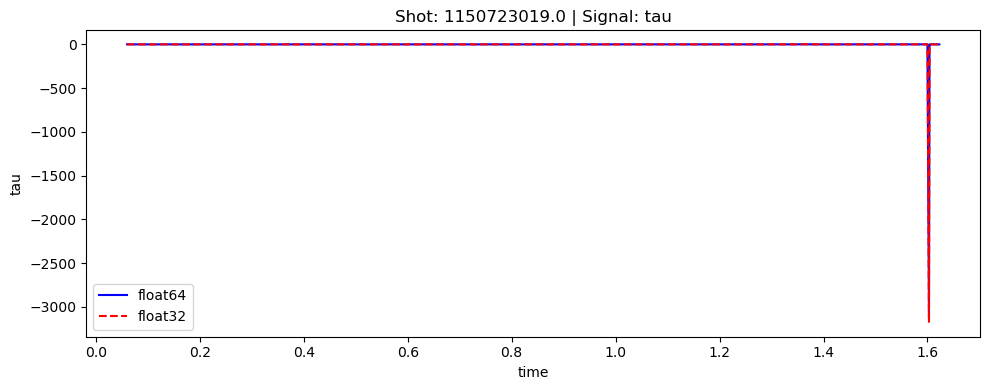

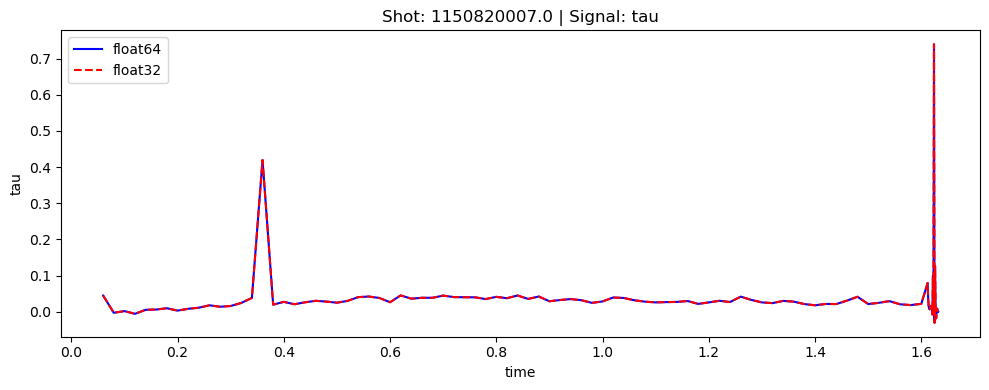

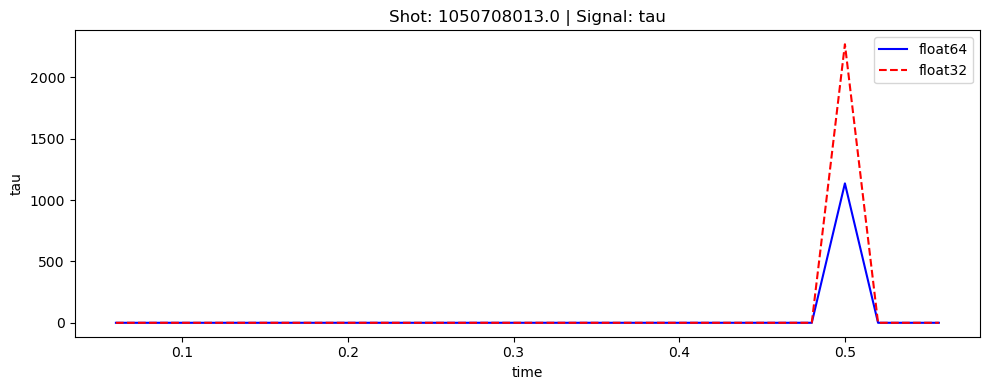

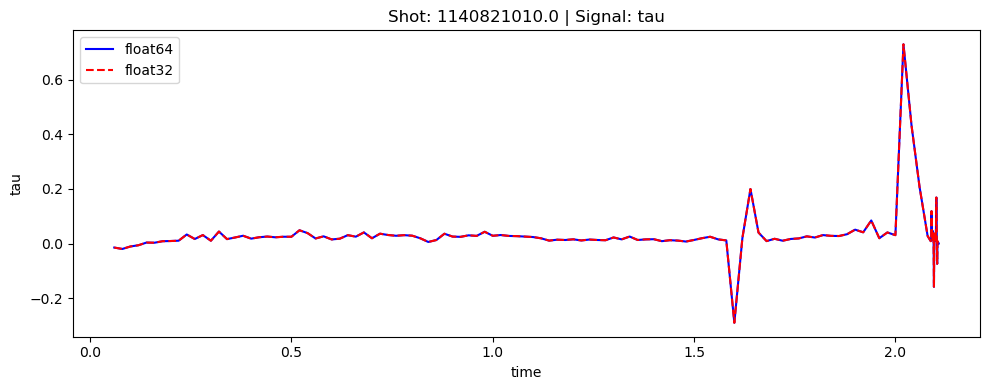

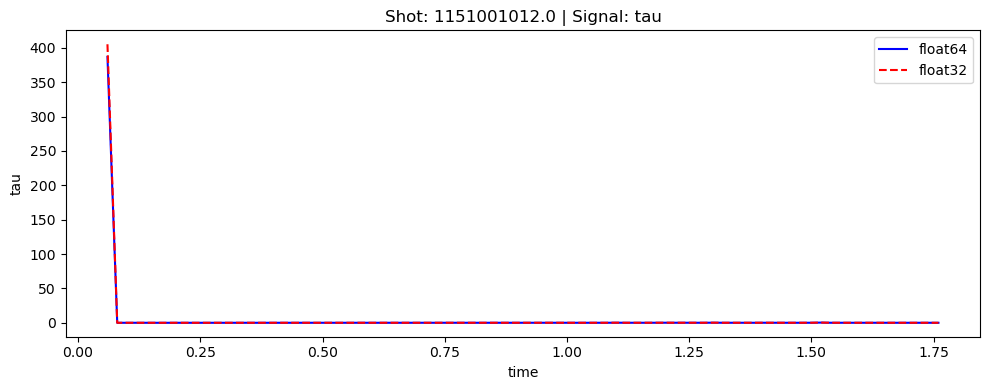

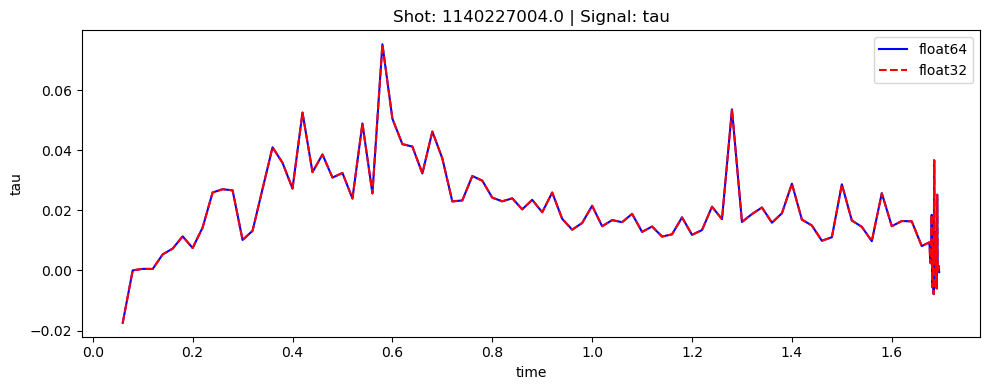

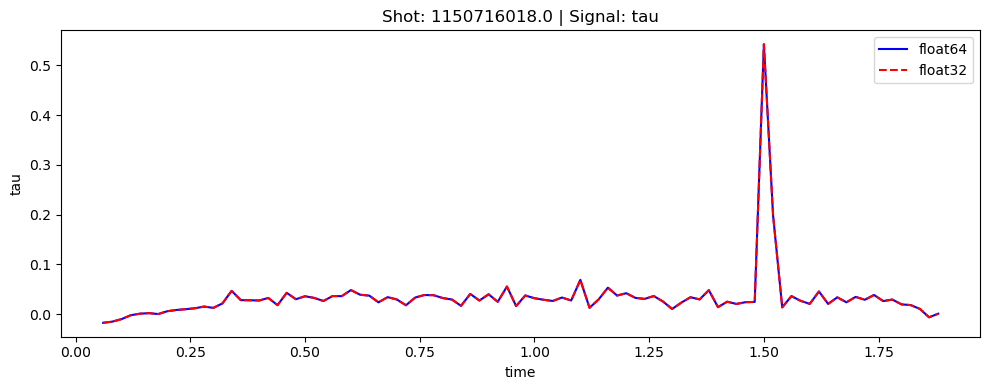

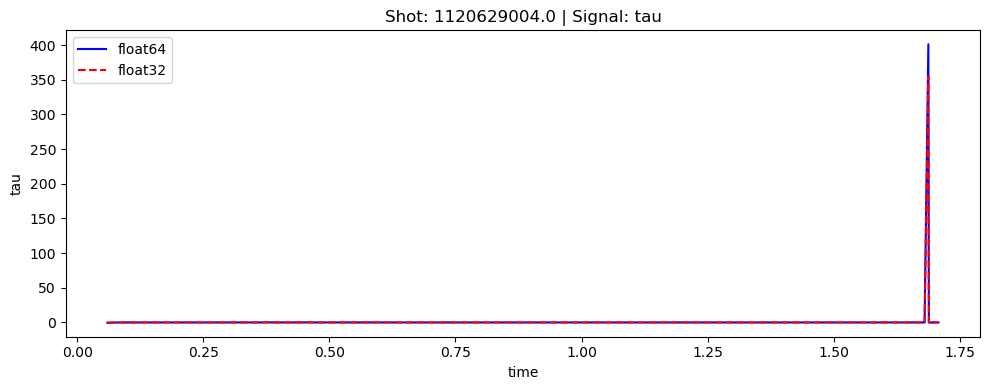

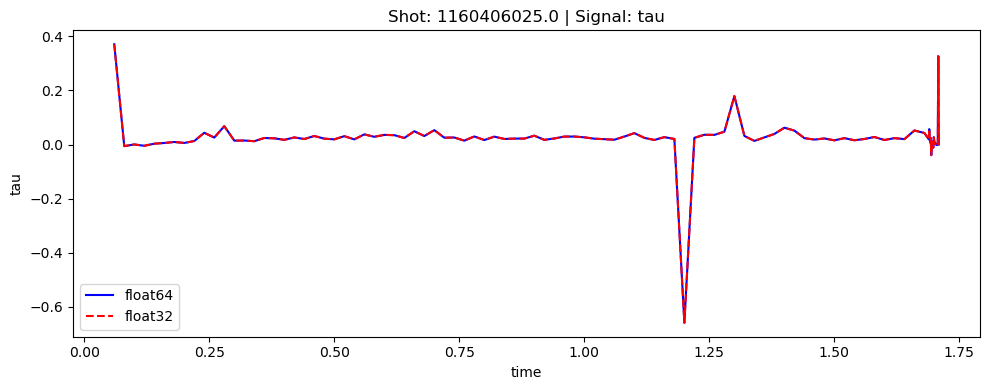

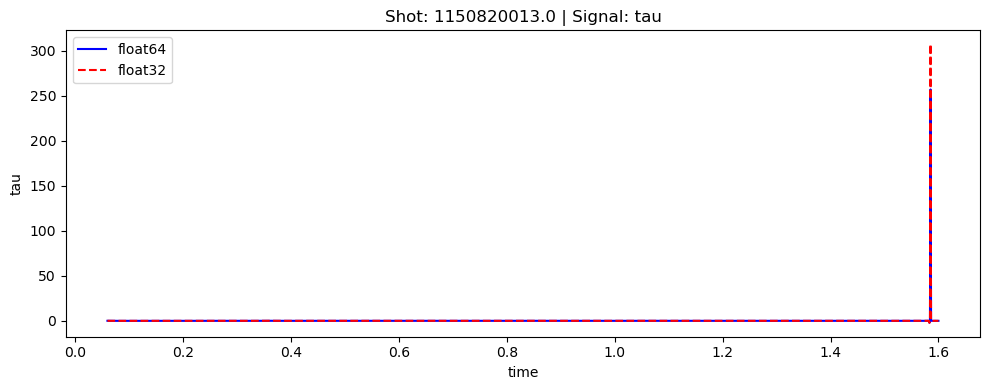

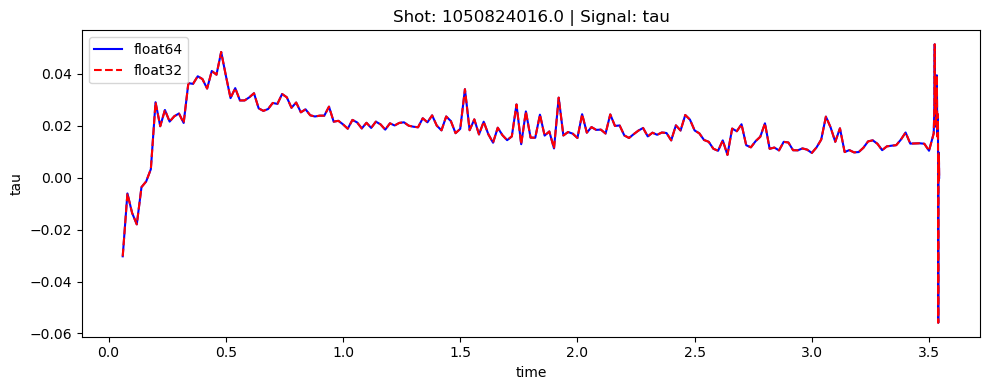

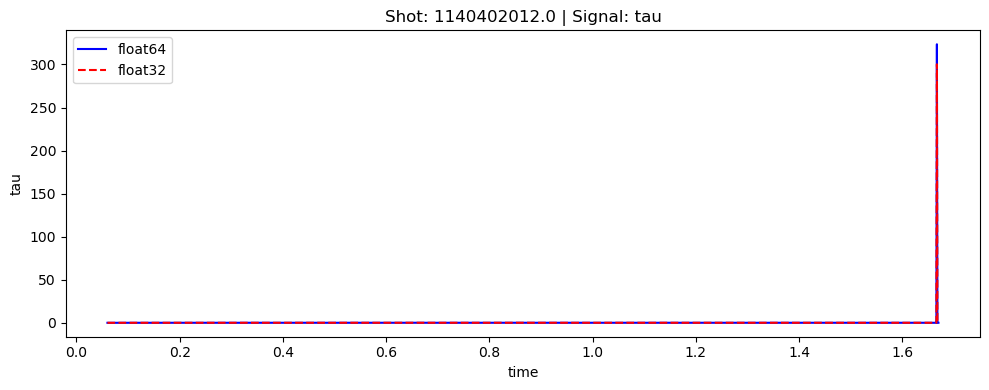

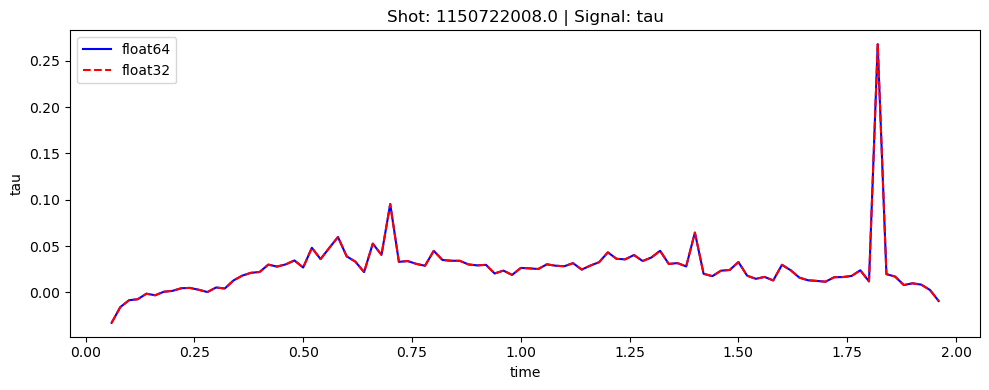

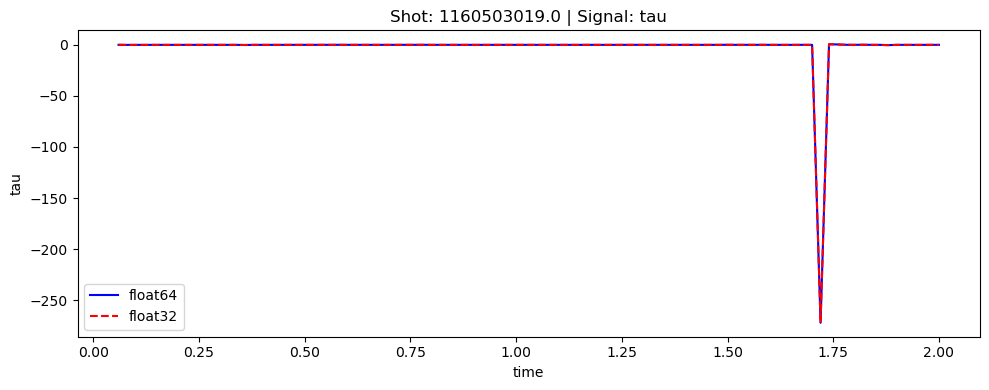

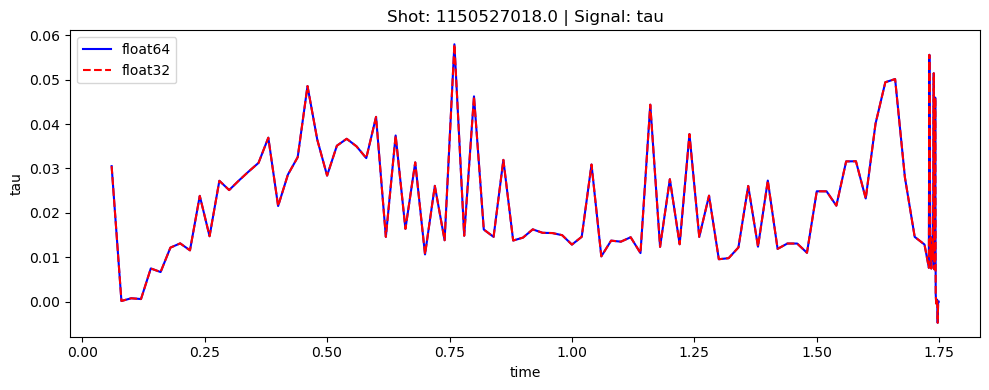

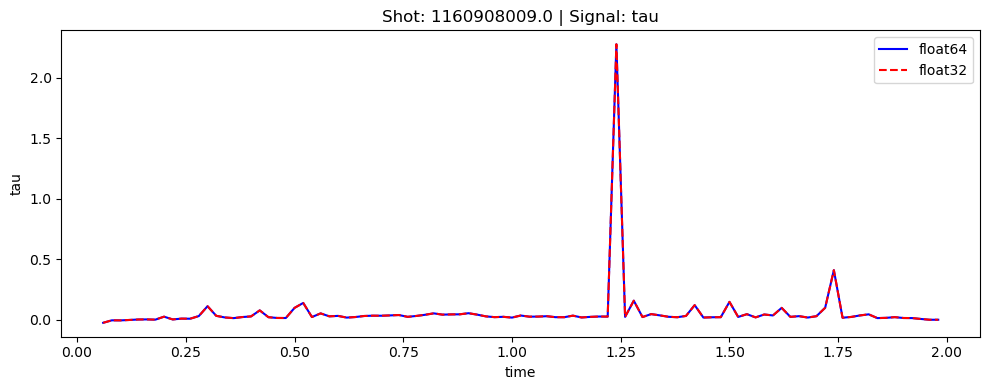

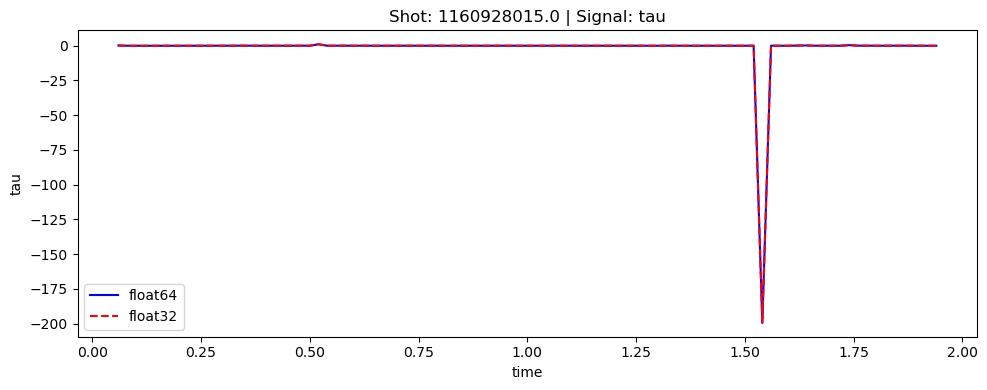

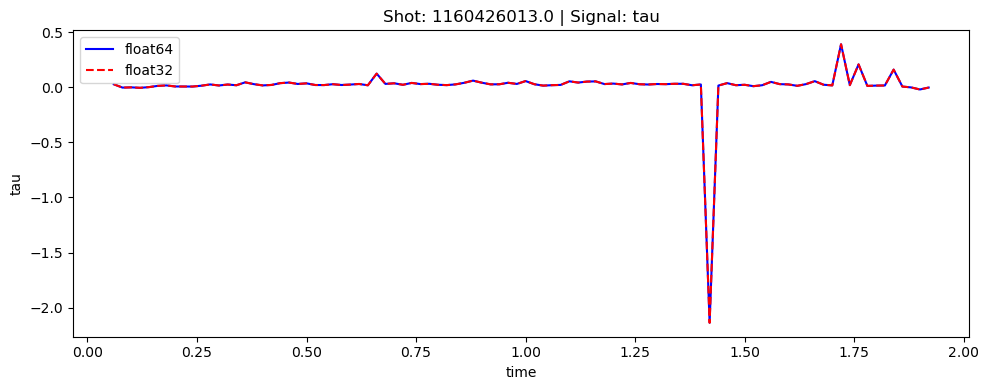

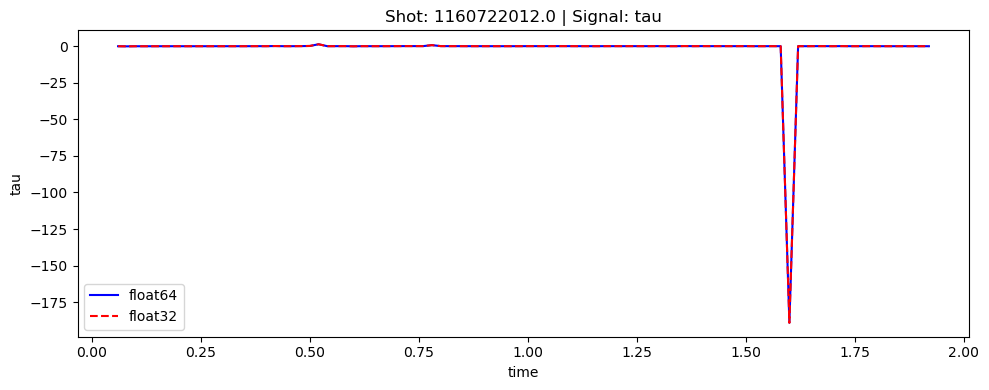

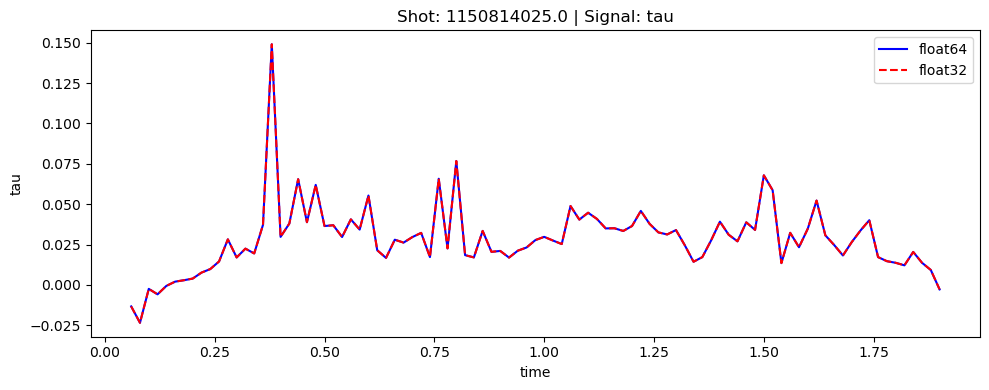

In [10]:
import matplotlib.pyplot as plt

for shot in shot_list[:20]:
    signal = 'tau'  # Change this to the signal you want to plot
    # Filter for the current shot
    df32_shot = df32[df32['shot'] == shot]
    df64_shot = df64[df64['shot'] == shot] 
    plt.figure(figsize=(10, 4))
    plt.plot(df64_shot['time'], df64_shot[signal], label='float64', color='b')
    plt.plot(df32_shot['time'], df32_shot[signal], label='float32', color='r', linestyle='--')
    # add an arrow to the plot indicating the maximum difference time
    # max_time = df32_shot.loc[row['row_index'], 'time']
    # max_value_32 = df32_shot.loc[row['row_index'], signal]
    # max_value_64 = df64_shot.loc[row['row_index'], signal]
    # plt.annotate('Max Diff', xy=(max_time, max_value_32), xytext=(max_time + 0.1*max_time, max_value_32 + 0.1*max_value_32),
                #  arrowprops=dict(facecolor='black', arrowstyle='->'))
    # plt.title(f"Shot: {shot} | Signal: {signal} | Max Diff: {row['absolute_difference']:.6f} | Rel Diff 64-32 : {row['relative_difference_64_percent']:.6f} %")
    plt.title(f"Shot: {shot} | Signal: {signal}")
    plt.xlabel('time')
    plt.ylabel(signal)
    plt.legend()
    plt.tight_layout()
    plt.show()

These catastrophic errors are very infrequent